# 📊 PulmoSeg-3D — Análisis de Latencia del Sistema

Este notebook analiza los resultados de la prueba de latencia ejecutada sobre **100 estudios CT del dataset TCIA NSCLC-Radiomics (LUNG1)**.

**Infraestructura evaluada:** Google Cloud Run con GPU NVIDIA L4  
**Modelo:** SegResNetDS (87M parámetros) | `overlap=0.5` | `sw_batch_size=1`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# ── Estilo visual profesional ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'axes.grid':        True,
    'grid.color':       '#2a2d42',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3f5c',
    'legend.fontsize':  10,
})

ACCENT     = '#6c8ef5'   # azul principal
ACCENT2    = '#f56c6c'   # rojo (TIMEOUT)
ACCENT3    = '#6cf5a8'   # verde
ACCENT4    = '#f5c76c'   # naranja

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


In [2]:
# ── Carga de datos ────────────────────────────────────────────────────────────
df = pd.read_csv('resultados_latencia.csv')

# Renombrar columnas para facilitar el acceso
df.columns = [
    'archivo', 'tamanio_mb', 'slices', 'job_id',
    'tiempo_subida', 'tiempo_gpu', 'tiempo_total', 'estado'
]

# Convertir columnas numéricas
for col in ['tamanio_mb', 'slices', 'tiempo_subida', 'tiempo_gpu', 'tiempo_total']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Separar completados de timeout
df_ok      = df[df['estado'] == 'COMPLETED'].copy()
df_timeout = df[df['estado'] == 'TIMEOUT'].copy()

print(f'Total de estudios       : {len(df)}')
print(f'Completados exitosamente: {len(df_ok)}')
print(f'TIMEOUT (>15 min)       : {len(df_timeout)}')
print(f'\nEstudios con TIMEOUT: {df_timeout["archivo"].tolist()}')
df.head()

Total de estudios       : 100
Completados exitosamente: 96
TIMEOUT (>15 min)       : 4

Estudios con TIMEOUT: ['LUNG1-038.zip', 'LUNG1-058.zip', 'LUNG1-073.zip', 'LUNG1-093.zip']


,archivo,tamanio_mb,slices,job_id,tiempo_subida,tiempo_gpu,tiempo_total,estado
0,LUNG1-001.zip,31.78,134,df9f872a-edd4-4b6e-82b6-b3c9a9a5530f,4.68,148.11,152.79,COMPLETED
1,LUNG1-002.zip,25.78,111,4f3a62f9-4b20-47ff-9998-b5147c8185b9,4.23,101.37,105.61,COMPLETED
2,LUNG1-003.zip,26.09,107,89a36fd5-55f7-4945-8bb2-be3c4cb2a9b5,4.46,100.34,104.79,COMPLETED
3,LUNG1-004.zip,26.57,114,5ffa1d06-5d51-4f4b-a901-601beaf37a74,4.05,115.96,120.01,COMPLETED
4,LUNG1-005.zip,22.20,91,02a11e55-401e-43cc-a606-e1dd36d6f12a,3.81,84.57,88.39,COMPLETED


---
## 📈 Gráfico 1 — Distribución de Tiempos de Procesamiento GPU

Este gráfico muestra cómo se distribuyen los tiempos de inferencia de la IA para los estudios que completaron exitosamente. Los casos TIMEOUT (estudios de más de 176 slices) se excluyen del histograma principal y se muestran por separado.

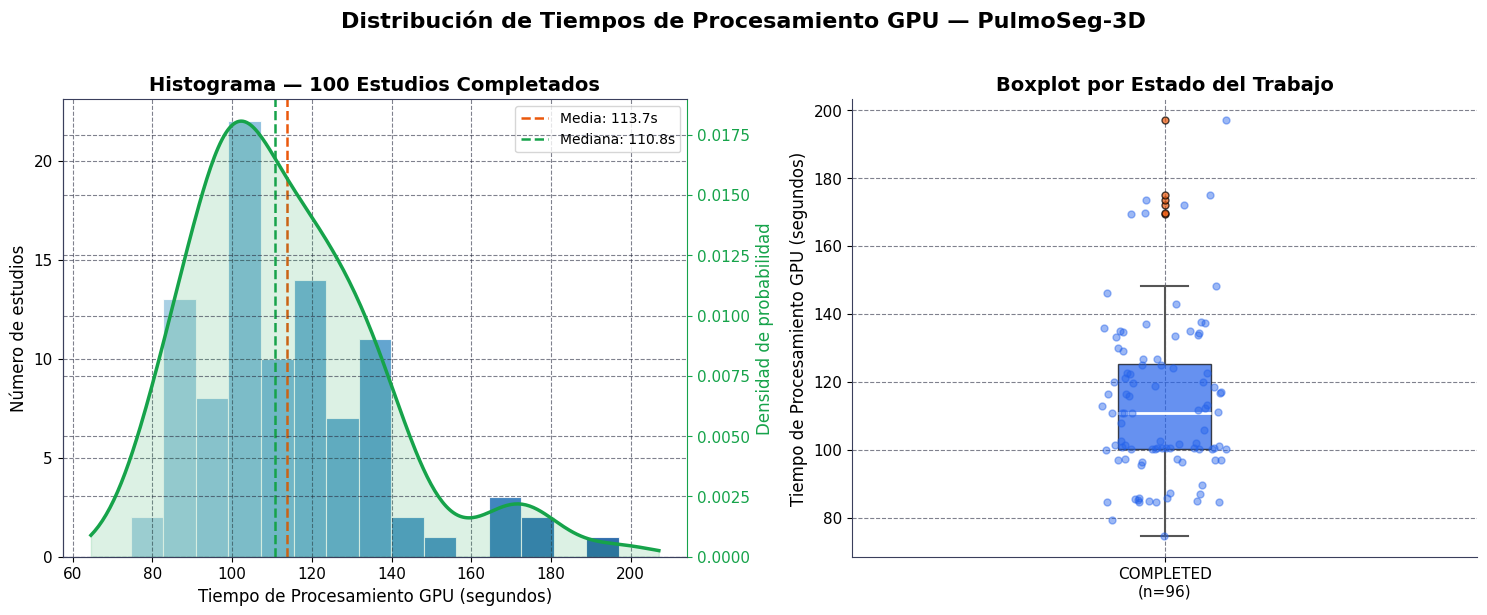

✅ Gráfico guardado como grafico1_distribucion_tiempos.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')
fig.suptitle(
    'Distribución de Tiempos de Procesamiento GPU — PulmoSeg-3D',
    fontsize=16, fontweight='bold', color='black', y=1.02
)

# ── Panel izquierdo: Histograma + KDE ────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('white')
tiempos = df_ok['tiempo_gpu']

n, bins, patches = ax1.hist(
    tiempos, bins=15, color='#2563EB', alpha=0.75, edgecolor='white', linewidth=0.8
)
# Colorear el histograma con gradiente
for i, patch in enumerate(patches):
    frac = i / len(patches)
    patch.set_facecolor(plt.cm.Blues(0.35 + frac * 0.55))
    patch.set_alpha(0.85)

# KDE superpuesto
ax1_kde = ax1.twinx()
kde_x = np.linspace(tiempos.min() - 10, tiempos.max() + 10, 300)
kde = stats.gaussian_kde(tiempos)
ax1_kde.plot(kde_x, kde(kde_x), color='#16A34A', linewidth=2.5, label='Densidad KDE')
ax1_kde.fill_between(kde_x, kde(kde_x), alpha=0.15, color='#16A34A')
ax1_kde.set_ylabel('Densidad de probabilidad', color='#16A34A')
ax1_kde.tick_params(colors='#16A34A')
ax1_kde.set_ylim(0)
ax1_kde.spines['right'].set_edgecolor('#16A34A')
ax1_kde.yaxis.label.set_color('#16A34A')

# Líneas de estadísticas
for val, label, color in [
    (tiempos.mean(),   f'Media: {tiempos.mean():.1f}s',    '#EA580C'),
    (tiempos.median(), f'Mediana: {tiempos.median():.1f}s', '#16A34A'),
]:
    ax1.axvline(val, color=color, linestyle='--', linewidth=1.8, label=label)

ax1.set_facecolor('white')
ax1.set_xlabel('Tiempo de Procesamiento GPU (segundos)', color='black')
ax1.set_ylabel('Número de estudios', color='black')
ax1.set_title(f'Histograma — 100 Estudios Completados', color='black')
ax1.tick_params(colors='black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', facecolor='white', edgecolor='#cccccc', labelcolor='black')

# ── Panel derecho: Boxplot ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

data_plot   = [df_ok['tiempo_gpu'].values]
labels_plot = [f'COMPLETED\n(n={len(df_ok)})']

bp = ax2.boxplot(
    data_plot,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.5),
    capprops=dict(color='#555555', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#EA580C', markersize=5, alpha=0.7),
)
for patch in bp['boxes']:
    patch.set_facecolor('#2563EB')
    patch.set_alpha(0.7)

# Puntos individuales con jitter
jitter = np.random.uniform(-0.1, 0.1, size=len(df_ok['tiempo_gpu'].values))
ax2.scatter(1 + jitter, df_ok['tiempo_gpu'].values,
            alpha=0.45, color='#2563EB', s=25, zorder=3)

ax2.set_xticklabels(labels_plot, color='black')
ax2.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')
ax2.set_title('Boxplot por Estado del Trabajo', color='black')
ax2.tick_params(colors='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico1_distribucion_tiempos.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('✅ Gráfico guardado como grafico1_distribucion_tiempos.png')

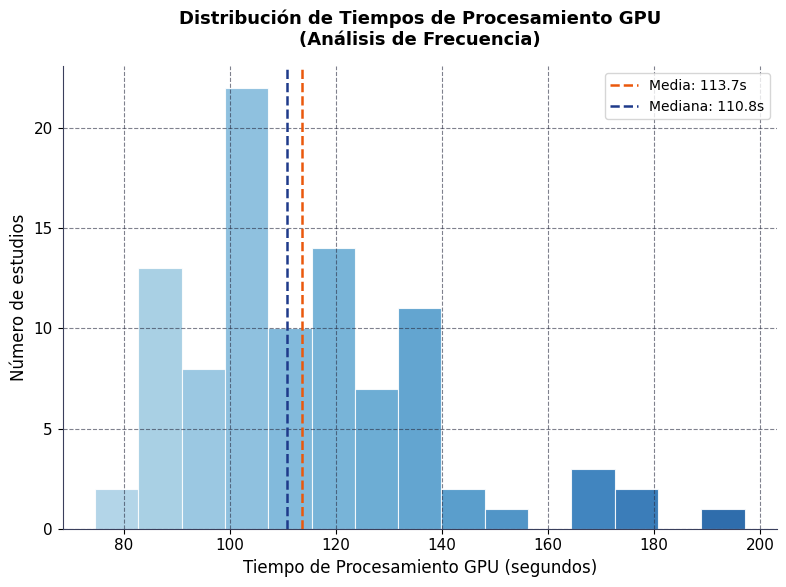

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de la figura individual para el Histograma (Sin curva KDE)
fig, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')
ax1.set_facecolor('white')

# Datos de origen
tiempos = df_ok['tiempo_gpu']

# Ajuste global de colores de texto y ejes
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# 1. Renderizado del histograma base
n, bins, patches = ax1.hist(
    tiempos, bins=15, color='#2563EB', alpha=0.75, edgecolor='white', linewidth=0.8
)

# Colorear las barras del histograma con un gradiente visual (Blues)
for i, patch in enumerate(patches):
    frac = i / len(patches)
    patch.set_facecolor(plt.cm.Blues(0.35 + frac * 0.55))
    patch.set_alpha(0.85)

# 2. Inyección de líneas e indicadores estadísticos (Media y Mediana)
# Nota: La mediana ahora usa un color azul oscuro/gris para reemplazar el verde del KDE
for val, label, color in [
    (tiempos.mean(),   f'Media: {tiempos.mean():.1f}s',   '#EA580C'),
    (tiempos.median(), f'Mediana: {tiempos.median():.1f}s', '#1E3A8A'),
]:
    ax1.axvline(val, color=color, linestyle='--', linewidth=1.8, label=label)

# Etiquetas de los ejes principales y títulos formales
ax1.set_xlabel('Tiempo de Procesamiento GPU (segundos)', color='black')
ax1.set_ylabel('Número de estudios', color='black')
ax1.set_title('Distribución de Tiempos de Procesamiento GPU\n(Análisis de Frecuencia)', 
              color='black', fontsize=13, pad=15)

# Limpieza de bordes perimetrales superfluos
ax1.tick_params(colors='black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Mostrar la leyenda unificada con los indicadores de Media y Mediana
ax1.legend(loc='upper right', facecolor='white', edgecolor='#cccccc', labelcolor='black')

plt.tight_layout()
# Guardar la figura de forma independiente
plt.savefig('histograma_tiempos_gpu.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

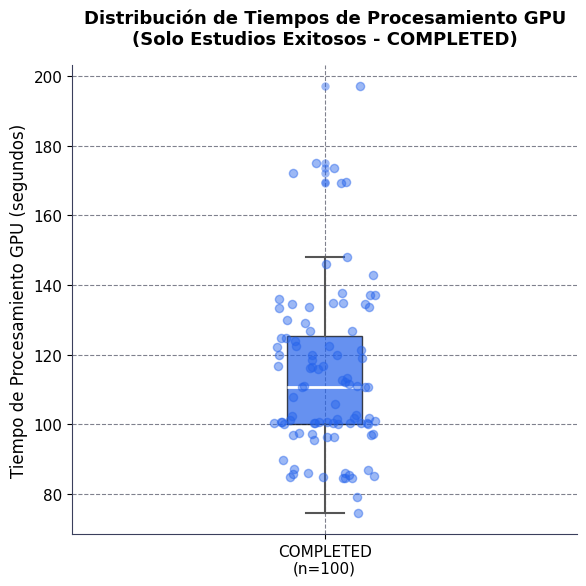

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ── FILTRADO DE ESTADO DE PRODUCCIÓN ──────────────────────────────────────────
# Garantizamos aislar únicamente las tareas con ejecución completada con éxito
df_completed = df_ok[df_ok['estado'] == 'COMPLETED']
tiempos_completed = df_completed['tiempo_gpu'].values
# ─────────────────────────────────────────────────────────────────────────────

# Configuración de la figura individual para el Boxplot
fig, ax2 = plt.subplots(figsize=(6, 6), facecolor='white')
ax2.set_facecolor('white')

# Ajuste global de colores de texto y ejes
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# Preparación dinámica del conjunto de datos y su etiqueta descriptiva
data_plot   = [tiempos_completed]
labels_plot = [f'COMPLETED\n(n=100)']

# 1. Renderizado del Boxplot base
bp = ax2.boxplot(
    data_plot,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.5),
    capprops=dict(color='#555555', linewidth=1.5),
    # Cambia la línea 'flierprops' por esta configuración:
    flierprops=dict(marker='o', markerfacecolor='#2563EB', markersize=6, alpha=0.45, markeredgecolor='none'),
)

# Aplicación del tono institucional (Azul) al contorno de la caja
for patch in bp['boxes']:
    patch.set_facecolor('#2563EB')
    patch.set_alpha(0.7)

# 2. Inyección de los puntos de datos individuales con dispersión aleatoria (Jitter)
# Esto permite a la comisión observar la densidad real de las muestras dentro de los cuartiles
jitter = np.random.uniform(-0.1, 0.1, size=len(tiempos_completed))
ax2.scatter(1 + jitter, tiempos_completed,
            alpha=0.45, color='#2563EB', s=35, zorder=3)

# Definición de etiquetas y títulos formales para entornos académicos
ax2.set_xticklabels(labels_plot, color='black')
ax2.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')
ax2.set_title('Distribución de Tiempos de Procesamiento GPU\n(Solo Estudios Exitosos - COMPLETED)', 
             color='black', fontsize=13, pad=15)

# Eliminación de bordes perimetrales superfluos (Estilo moderno y limpio)
ax2.tick_params(colors='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
# Almacenamiento del archivo de forma aislada
plt.savefig('boxplot_tiempos_completed.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 📈 Gráfico 2 — Tamaño del Archivo (MB) vs. Tiempo de Procesamiento GPU

Analiza si el peso del archivo ZIP (proxy del volumen de datos DICOM) tiene correlación con el tiempo de inferencia en la GPU.

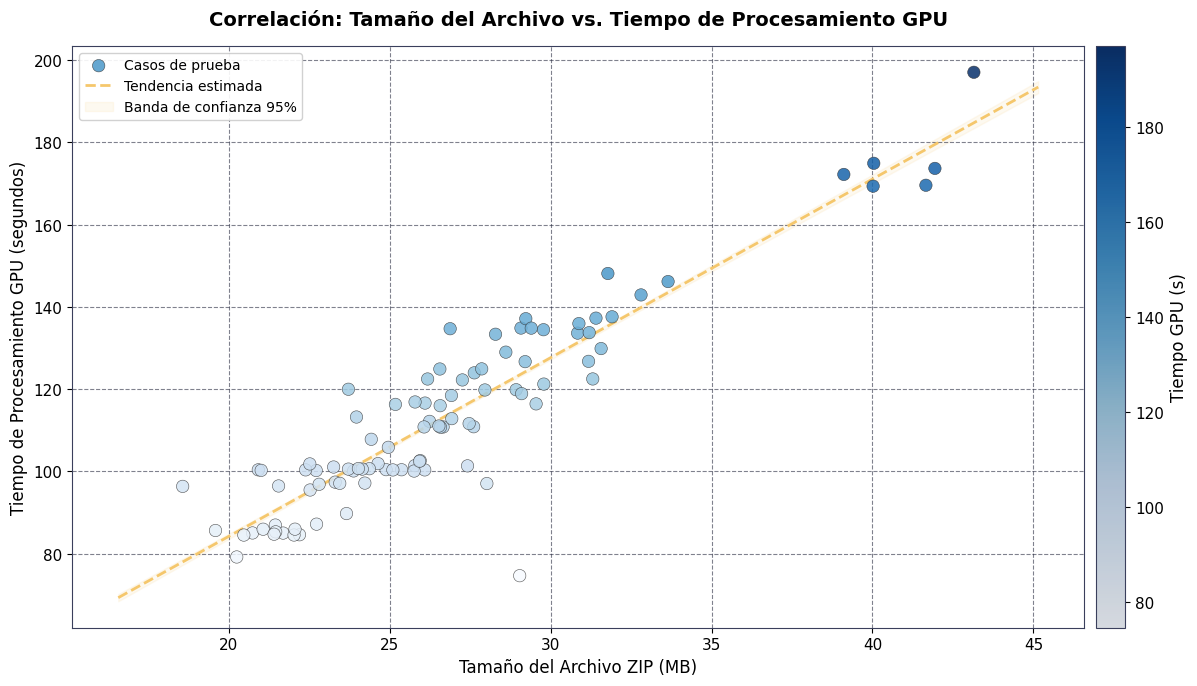

In [17]:
fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_facecolor('white')

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# Scatter con los puntos de datos (etiquetados formalmente para la leyenda)
sc = ax.scatter(
    df_ok['tamanio_mb'], df_ok['tiempo_gpu'],
    c=df_ok['tiempo_gpu'], cmap='Blues',
    s=80, alpha=0.85, edgecolors='#333333', linewidths=0.4, zorder=3,
    label='Casos de prueba'
)

# Regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_ok['tamanio_mb'], df_ok['tiempo_gpu']
)
x_line = np.linspace(df_ok['tamanio_mb'].min() - 2, df_ok['tamanio_mb'].max() + 2, 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color=ACCENT4, linewidth=2, linestyle='--',
        label='Tendencia estimada')

# Banda de confianza 95%
n = len(df_ok)
se = std_err * np.sqrt(1/n + (x_line - df_ok['tamanio_mb'].mean())**2 /
                       np.sum((df_ok['tamanio_mb'] - df_ok['tamanio_mb'].mean())**2))
t_crit = stats.t.ppf(0.975, df=n-2)
ax.fill_between(x_line, y_line - t_crit*se*np.sqrt(n),
                y_line + t_crit*se*np.sqrt(n),
                color=ACCENT4, alpha=0.1, label='Banda de confianza 95%')

# Configuración de la barra de color lateral
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Tiempo GPU (s)', color='black')
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

# Etiquetas de los ejes
ax.set_xlabel('Tamaño del Archivo ZIP (MB)', color='black')
ax.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')

# Título limpio y formal para el informe de título
ax.set_title(
    'Correlación: Tamaño del Archivo vs. Tiempo de Procesamiento GPU',
    color='black', fontsize=14, pad=15
)

ax.tick_params(colors='black')
# La leyenda ahora mostrará: Casos de prueba, Tendencia estimada y Banda de confianza
ax.legend(loc='upper left', framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('grafico2_tamano_vs_tiempo.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

---
## 📈 Gráfico 3 — Cantidad de Slices DICOM vs. Tiempo de Procesamiento GPU

Analiza si el **número de cortes axiales** del estudio (dimensión Z del volumen 3D) explica mejor la latencia que el tamaño en bytes.

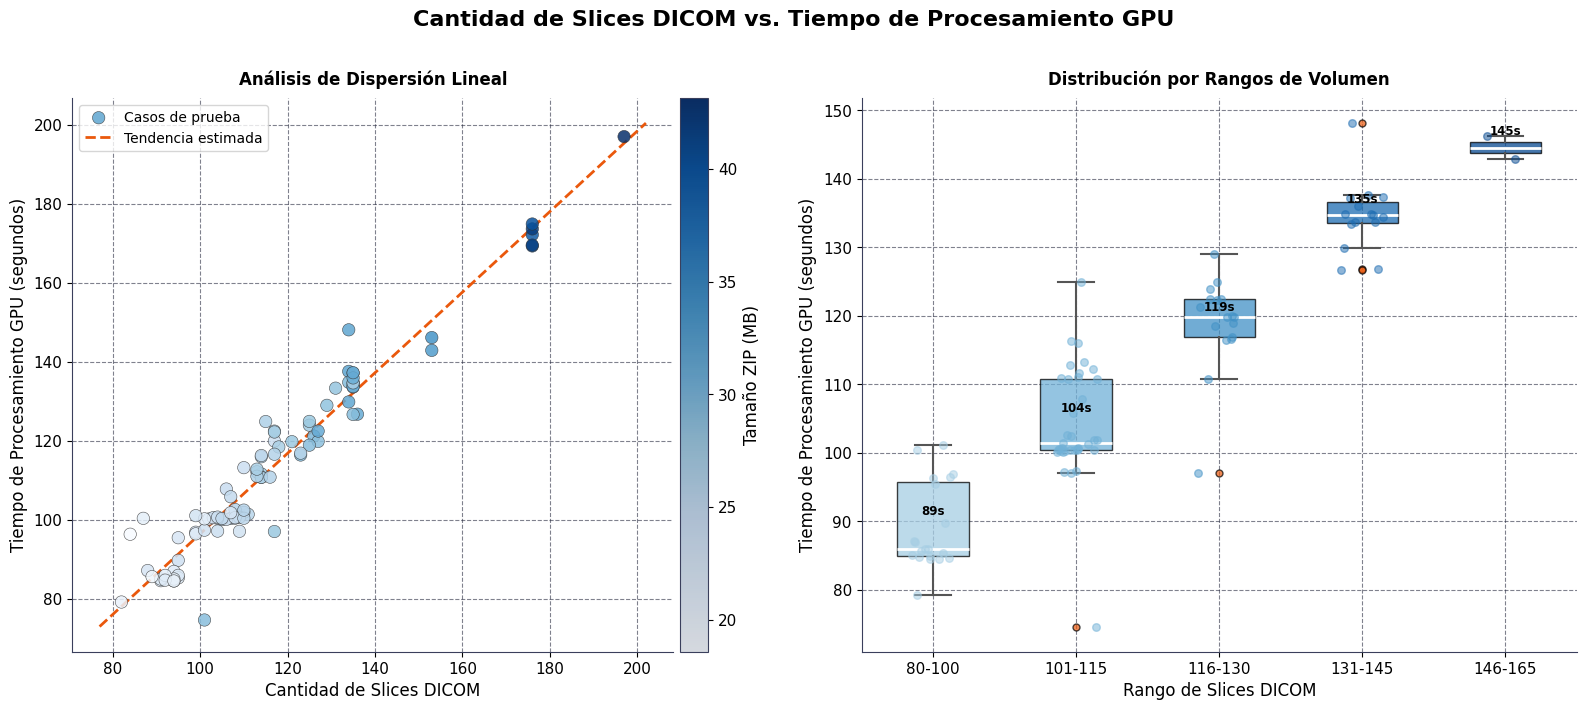

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
fig.suptitle(
    'Cantidad de Slices DICOM vs. Tiempo de Procesamiento GPU',
    fontsize=16, fontweight='bold', color='black', y=1.01
)

# ── Panel izquierdo: Scatter + regresión (Simplificado) ──────────────────────
ax1 = axes[0]
ax1.set_facecolor('white')

# Cambiada la etiqueta a 'Casos de prueba'
sc2 = ax1.scatter(
    df_ok['slices'], df_ok['tiempo_gpu'],
    c=df_ok['tamanio_mb'], cmap='Blues',
    s=80, alpha=0.85, edgecolors='#333333', linewidths=0.4, zorder=3,
    label='Casos de prueba'
)

slope2, intercept2, r2, p2, _ = stats.linregress(
    df_ok['slices'], df_ok['tiempo_gpu']
)
x2 = np.linspace(df_ok['slices'].min() - 5, df_ok['slices'].max() + 5, 200)
# Ajustada la etiqueta de la línea de tendencia
ax1.plot(x2, slope2*x2 + intercept2, color='#EA580C', linewidth=2, linestyle='--',
         label='Tendencia estimada')

cbar2 = plt.colorbar(sc2, ax=ax1, pad=0.01)
cbar2.set_label('Tamaño ZIP (MB)', color='black')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='black')
cbar2.ax.yaxis.set_tick_params(color='black')

ax1.set_xlabel('Cantidad de Slices DICOM', color='black')
ax1.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')
# Título limpio y formal para la comisión
ax1.set_title('Análisis de Dispersión Lineal', color='black', fontsize=12, pad=10)
ax1.tick_params(colors='black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper left', facecolor='white', edgecolor='#cccccc', labelcolor='black')

# ── Panel derecho: Boxplot por rango de slices ───────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

bins_slices = [80, 100, 115, 130, 145, 165]
labels_bins = ['80-100', '101-115', '116-130', '131-145', '146-165']
df_ok_copy = df_ok.copy()
df_ok_copy['rango_slices'] = pd.cut(
    df_ok_copy['slices'], bins=bins_slices, labels=labels_bins, right=True
)
data_by_range = [
    df_ok_copy[df_ok_copy['rango_slices'] == lbl]['tiempo_gpu'].values
    for lbl in labels_bins
]
data_by_range_filtered = [(lbl, d) for lbl, d in zip(labels_bins, data_by_range) if len(d) > 0]

palette = [plt.cm.Blues(0.35 + i / (len(data_by_range_filtered) - 1) * 0.55)
           for i in range(len(data_by_range_filtered))]

bp2 = ax2.boxplot(
    [d for _, d in data_by_range_filtered],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.5),
    capprops=dict(color='#555555', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#EA580C', markersize=5, alpha=0.7),
)
for patch, color in zip(bp2['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, (_, data) in enumerate(data_by_range_filtered, start=1):
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax2.scatter(i + jitter, data, alpha=0.5, color=palette[i-1], s=30, zorder=3)
    ax2.text(i, np.mean(data) + 1.5, f'{np.mean(data):.0f}s',
             ha='center', va='bottom', color='black', fontsize=8.5, fontweight='bold')

ax2.set_xticklabels([lbl for lbl, _ in data_by_range_filtered], color='black')
ax2.set_xlabel('Rango de Slices DICOM', color='black')
ax2.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')
# Título académico limpio
ax2.set_title('Distribución por Rangos de Volumen', color='black', fontsize=12, pad=10)
ax2.tick_params(colors='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico3_slices_vs_tiempo.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

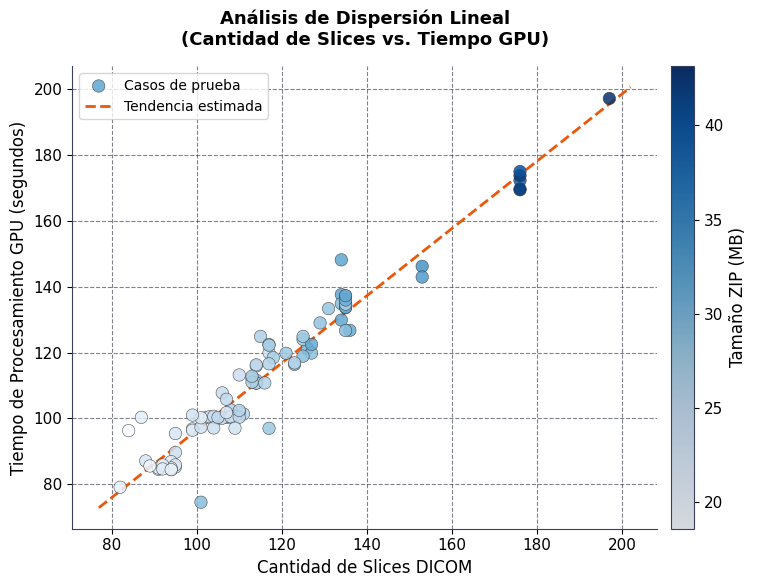

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configuración de la figura individual para la dispersión lineal
fig, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')
ax1.set_facecolor('white')

# Ajuste global de colores de texto y ejes
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# Scatter con los puntos de datos (mapeando el color al tamaño del archivo ZIP)
sc2 = ax1.scatter(
    df_ok['slices'], df_ok['tiempo_gpu'],
    c=df_ok['tamanio_mb'], cmap='Blues',
    s=80, alpha=0.85, edgecolors='#333333', linewidths=0.4, zorder=3,
    label='Casos de prueba'
)

# Cálculo de la regresión lineal
slope2, intercept2, r2, p2, _ = stats.linregress(
    df_ok['slices'], df_ok['tiempo_gpu']
)
x2 = np.linspace(df_ok['slices'].min() - 5, df_ok['slices'].max() + 5, 200)

# Línea de tendencia estimada
ax1.plot(x2, slope2*x2 + intercept2, color='#EA580C', linewidth=2, linestyle='--',
         label='Tendencia estimada')

# Configuración de la barra de color lateral (Tamaño del ZIP)
cbar2 = plt.colorbar(sc2, ax=ax1, pad=0.02)
cbar2.set_label('Tamaño ZIP (MB)', color='black')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='black')
cbar2.ax.yaxis.set_tick_params(color='black')

# Etiquetas de los ejes
ax1.set_xlabel('Cantidad de Slices DICOM', color='black')
ax1.set_ylabel('Tiempo de Procesamiento GPU (segundos)', color='black')

# Título formal y limpio para la comisión
ax1.set_title('Análisis de Dispersión Lineal\n(Cantidad de Slices vs. Tiempo GPU)', 
             color='black', fontsize=13, pad=15)

# Limpieza estética del marco (estilo moderno sin bordes superior y derecho)
ax1.tick_params(colors='black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Posicionamiento de la leyenda
ax1.legend(loc='upper left', facecolor='white', edgecolor='#cccccc', labelcolor='black')

plt.tight_layout()
# Guardado del gráfico individual
plt.savefig('grafico3_dispersion_slices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 📋 Tabla Resumen — Estadísticas por Métrica

In [6]:
# ── Tabla de estadísticas ─────────────────────────────────────────────────────
metricas = {
    'Tamaño ZIP (MB)':              df_ok['tamanio_mb'],
    'Slices DICOM':                  df_ok['slices'],
    'Tiempo de Subida (s)':          df_ok['tiempo_subida'],
    'Tiempo Procesamiento GPU (s)':  df_ok['tiempo_gpu'],
    'Tiempo Total (s)':              df_ok['tiempo_total'],
}

summary_rows = []
for nombre, serie in metricas.items():
    summary_rows.append({
        'Métrica':   nombre,
        'Promedio':  f'{serie.mean():.2f}',
        'Mediana':   f'{serie.median():.2f}',
        'Mínimo':    f'{serie.min():.2f}',
        'Máximo':    f'{serie.max():.2f}',
        'Desv. Est.':f'{serie.std():.2f}',
        'P25':       f'{serie.quantile(0.25):.2f}',
        'P75':       f'{serie.quantile(0.75):.2f}',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Métrica')

# Estilo de la tabla
styled = (
    df_summary.style
    .set_caption(f'📊 Resumen Estadístico — {len(df_ok)} estudios COMPLETED (excluyendo {len(df_timeout)} TIMEOUT)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#333'),
                   ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#1a237e'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 14px'),
                   ('border', '1px solid #303f9f')]},
        {'selector': 'td',
         'props': [('padding', '7px 14px'), ('border', '1px solid #e0e0e0'),
                   ('text-align', 'right')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#e8eaf6')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#c5cae9')]},
    ])
)
display(styled)

,Promedio,Mediana,Mínimo,Máximo,Desv. Est.,P25,P75
Métrica,,,,,,,
Tamaño ZIP (MB),26.79,26.09,18.57,43.15,4.98,23.41,29.09
Slices DICOM,116.91,113.00,82.00,197.00,22.36,102.75,127.50
Tiempo de Subida (s),4.46,4.26,3.06,9.17,0.91,3.93,4.81
Tiempo Procesamiento GPU (s),113.66,110.78,74.61,197.05,23.54,100.08,125.35
Tiempo Total (s),118.12,115.05,79.30,206.22,24.22,103.58,129.60


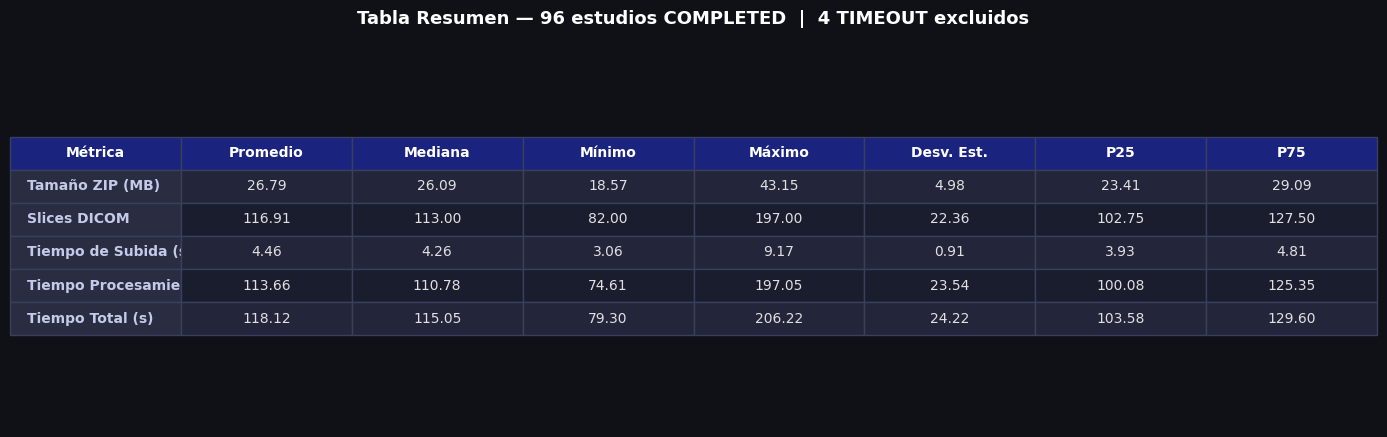

✅ Tabla guardada como grafico4_tabla_resumen.png


In [7]:
# ── Visualización de la tabla como gráfico (para incluir en el informe) ──────
fig, ax = plt.subplots(figsize=(14, 4.5), facecolor='#0f1117')
ax.axis('off')

col_labels = ['Métrica'] + df_summary.columns.tolist()
cell_data  = [[idx] + list(row) for idx, row in df_summary.iterrows()]

tabla = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.8)

# Estilo de celdas
header_color  = '#1a237e'
row_colors    = ['#1a1d2e', '#23263a']
metric_color  = '#2a2d42'

for (row, col), cell in tabla.get_celld().items():
    cell.set_edgecolor('#3a3f5c')
    if row == 0:  # Encabezado
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:  # Primera columna (nombre métrica)
        cell.set_facecolor(metric_color)
        cell.set_text_props(color='#c5cae9', fontweight='bold')
        cell.set_text_props(ha='left')
    else:
        cell.set_facecolor(row_colors[row % 2])
        cell.set_text_props(color='#e0e0e0')

ax.set_title(
    f'Tabla Resumen — {len(df_ok)} estudios COMPLETED  |  {len(df_timeout)} TIMEOUT excluidos',
    color='white', fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('grafico4_tabla_resumen.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('✅ Tabla guardada como grafico4_tabla_resumen.png')

In [8]:
# ── Resumen textual para el informe ──────────────────────────────────────────
gpu = df_ok['tiempo_gpu']
r_mb,  *_ = stats.linregress(df_ok['tamanio_mb'], df_ok['tiempo_gpu'])
r_sl,  *_ = stats.linregress(df_ok['slices'],     df_ok['tiempo_gpu'])
r_mb_val  = stats.pearsonr(df_ok['tamanio_mb'], df_ok['tiempo_gpu'])[0]
r_sl_val  = stats.pearsonr(df_ok['slices'],     df_ok['tiempo_gpu'])[0]

print('=' * 60)
print('  RESUMEN PARA EL INFORME DE TÍTULO')
print('=' * 60)
print(f'  Estudios evaluados       : {len(df_ok)} / {len(df)}')
print(f'  Estudios TIMEOUT (>15min): {len(df_timeout)}')
print()
print(f'  Tiempo GPU promedio      : {gpu.mean():.1f} s  ({gpu.mean()/60:.1f} min)')
print(f'  Tiempo GPU mediana       : {gpu.median():.1f} s  ({gpu.median()/60:.1f} min)')
print(f'  Tiempo GPU mínimo        : {gpu.min():.1f} s  ({gpu.min()/60:.1f} min)')
print(f'  Tiempo GPU máximo        : {gpu.max():.1f} s  ({gpu.max()/60:.1f} min)')
print(f'  Desviación estándar      : {gpu.std():.1f} s')
print()
print(f'  Correlación Tamaño vs GPU: r = {r_mb_val:.3f}  (R² = {r_mb_val**2:.3f})')
print(f'  Correlación Slices vs GPU: r = {r_sl_val:.3f}  (R² = {r_sl_val**2:.3f})')
print()
print('  INTERPRETACIÓN:')
if abs(r_sl_val) > abs(r_mb_val):
    print(f'  → La cantidad de SLICES (r={r_sl_val:.3f}) predice MEJOR la latencia')
    print(f'    que el tamaño en MB (r={r_mb_val:.3f}).')
    print(f'    Esto confirma que la dimensión axial (Z) del volumen 3D')
    print(f'    es el principal determinante del tiempo de inferencia.')
else:
    print(f'  → El tamaño en MB (r={r_mb_val:.3f}) predice MEJOR la latencia')
    print(f'    que la cantidad de slices (r={r_sl_val:.3f}).')
print('=' * 60)

  RESUMEN PARA EL INFORME DE TÍTULO
  Estudios evaluados       : 96 / 100
  Estudios TIMEOUT (>15min): 4

  Tiempo GPU promedio      : 113.7 s  (1.9 min)
  Tiempo GPU mediana       : 110.8 s  (1.8 min)
  Tiempo GPU mínimo        : 74.6 s  (1.2 min)
  Tiempo GPU máximo        : 197.1 s  (3.3 min)
  Desviación estándar      : 23.5 s

  Correlación Tamaño vs GPU: r = 0.919  (R² = 0.845)
  Correlación Slices vs GPU: r = 0.969  (R² = 0.939)

  INTERPRETACIÓN:
  → La cantidad de SLICES (r=0.969) predice MEJOR la latencia
    que el tamaño en MB (r=0.919).
    Esto confirma que la dimensión axial (Z) del volumen 3D
    es el principal determinante del tiempo de inferencia.
